In [1]:
import sys
from pathlib import Path

# so that `paths.py` (with PROJECT_ROOT) is on the import path
sys.path.append(str(Path().resolve().parent))
from paths import PROJECT_ROOT

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dreams.utils.data import MSData
from dreams.algorithms.lsh import BatchedPeakListRandomProjection
from dreams.utils.spectra import PeakListModifiedCosine
from dreams.utils.plots import init_plotting

from benchmark.utils.plots import plot_similarity_kde, plot_dissimilarity_hist_kde

/Users/macbook/UTILS/anaconda3/envs/dreams_mimb/lib/python3.11/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


In [2]:
spectra_path = PROJECT_ROOT / "data" / "Piper_sirius_matched_annotated.mgff"
h5_path   = spectra_path.with_name(spectra_path.stem + ".hdf5")
dedup_h5  = spectra_path.with_name(spectra_path.stem + ".hdf5")

In [3]:
if h5_path.exists():
    # If the HDF5 already exists, load it directly (this is fastest)
    msdata = MSData.from_hdf5(h5_path, in_mem=True)
else:
    # If not, convert from the original file and cache the result as HDF5
    msdata = MSData.load(
        spectra_path,
        in_mem=True,
        prec_mz_col="PRECURSOR_MZ"
    )

Loading dataset Piper_sirius_matched_annotated into memory (224 spectra)...


In [4]:
specs = msdata.get_spectra()

lsh_proj = BatchedPeakListRandomProjection(bin_step=0.5, n_hyperplanes=50)
hashes   = lsh_proj.compute(specs)

print(f"▶ Computed {len(hashes)} hashes; example hash: {hashes[0]!r}")

Computing LSHs: 100%|██████████| 224/224 [00:00<00:00, 939.82it/s]


▶ Computed 224 hashes; example hash: b'095c8c1f4fde8ffbd535b0fec0bd8a0509cdd6665df8efafa58a4ad64eaa52d5'


In [6]:
ls     = pd.Series(hashes)
counts = ls.value_counts()

/var/folders/bl/73ckjztx5js4cc0cj85qgvlm0000gn/T/ipykernel_83096/3383496389.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  counts = ls.value_counts()


In [7]:
small_hash = counts[counts == 5].index
assert len(small_hash) > 0, "No cluster of size 5 found!"
small_hash = small_hash[0]
small_idxs = np.where(hashes == small_hash)[0]
print(f"▶ Small cluster hash {small_hash!r} at indices", small_idxs)

▶ Small cluster hash b'4efbf43b17feffc843b5aa9197e8230fcf7030df81c4116091f949d080c7940d' at indices [66 69 74 75 76]


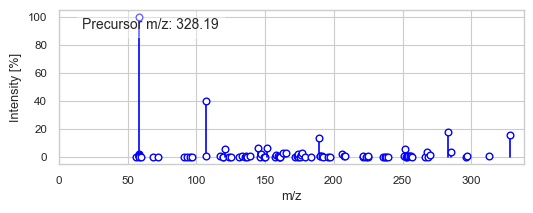

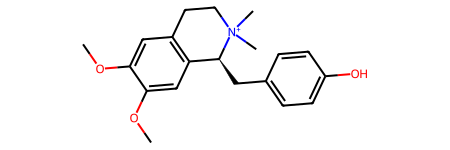

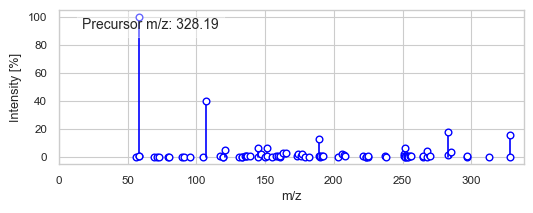

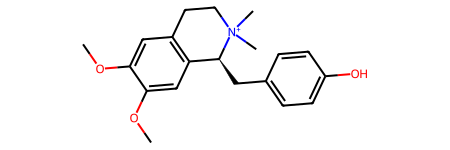

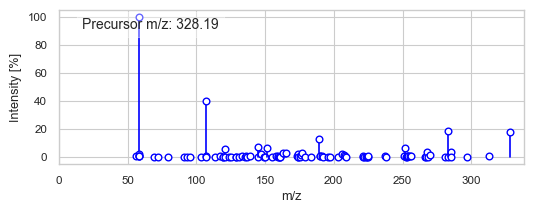

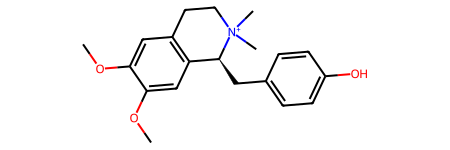

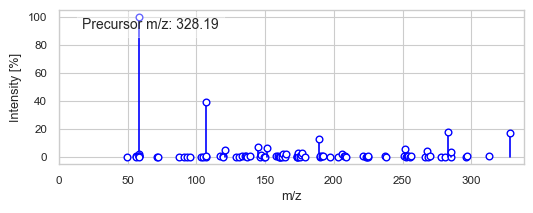

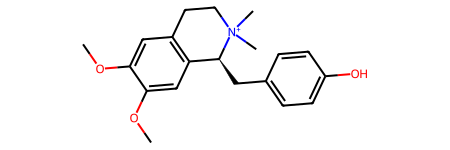

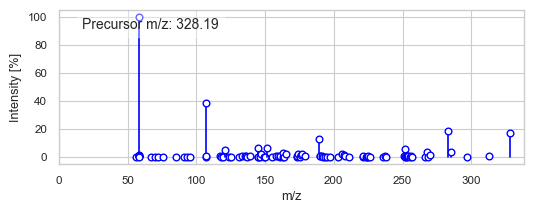

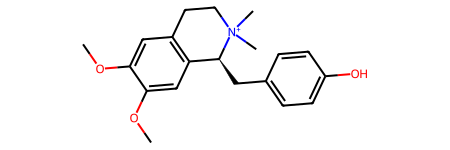

In [8]:
for raw_i in small_idxs:
    i = int(raw_i)
    msdata.at(i, plot_mol=True)

# NEW CLASS

In [9]:
msg_path      = PROJECT_ROOT / "data" / "massspecgym" / "MassSpecGym.mgf"
h5_path   = msg_path.with_name(msg_path.stem + ".hdf5")


In [10]:
if h5_path.exists():
    # If the HDF5 already exists, load it directly (this is fastest)
    msdata = MSData.from_hdf5(h5_path, in_mem=True)
else:
    # If not, convert from the original file and cache the result as HDF5
    msdata = MSData.load(
        msg_path,
        in_mem=True,
        prec_mz_col="PRECURSOR_MZ"
    )

Loading dataset MassSpecGym into memory (231104 spectra)...


In [11]:
specs = msdata.get_spectra()

lsh_proj = BatchedPeakListRandomProjection(bin_step=0.5, n_hyperplanes=50)
hashes   = lsh_proj.compute(specs)

print(f"▶ Computed {len(hashes)} hashes; example hash: {hashes[0]!r}")

Computing LSHs: 100%|██████████| 231104/231104 [01:10<00:00, 3286.15it/s]


▶ Computed 231104 hashes; example hash: b'd1595b0fc87e45da6d813214f3f1cf26427e117d0c5c353b9f7f0ba4cefe0e2a'


In [16]:
ls     = pd.Series(hashes)
lsh_counts = ls.value_counts()

print("▶ Total unique hashes (clusters):", lsh_counts.size)
print("▶ Top 5 cluster sizes:")
print(lsh_counts.head())

/var/folders/bl/73ckjztx5js4cc0cj85qgvlm0000gn/T/ipykernel_83096/3687234620.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  lsh_counts = ls.value_counts()


▶ Total unique hashes (clusters): 133471
▶ Top 5 cluster sizes:
b'bfae93ce054b4edc7aa794552cf5223a8c160080e7c8a7b02b6fe3fe8db2f8ee'    6339
b'5b3cff2b5c34fa13f93a8f47abd4a6582ddb49cc5625b368e9d1aba7e5c90d5a'     375
b'36235fd6ed50565f2733dc3de3c9291e1b077d730eef162c6f0ad9c557c56ba5'     248
b'b56df9a9acc1c00ee8ae8f0f407c717da687294d91c3b19fe278fdb03933d7e0'     247
b'670c7ff542d5d07ac07a9b7fd90a58f0aa23d34bcbafec5adab463f33692a67d'     234
Name: count, dtype: int64


/var/folders/bl/73ckjztx5js4cc0cj85qgvlm0000gn/T/ipykernel_83096/1657577487.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  lsh_counts = pd.Series(hashes).value_counts()


16879


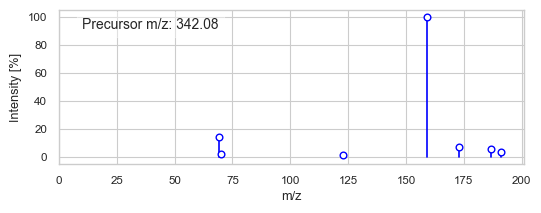

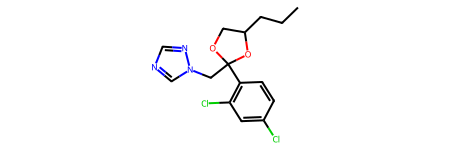

{'COLLISION_ENERGY': 40.0, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020702', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'QTOF', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}
16883


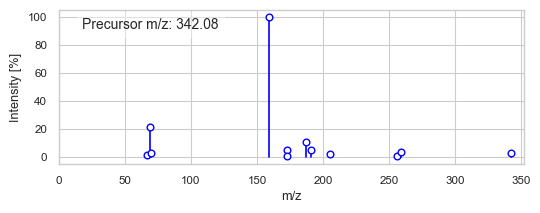

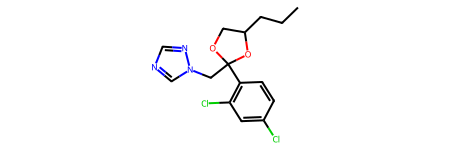

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020706', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}
16893


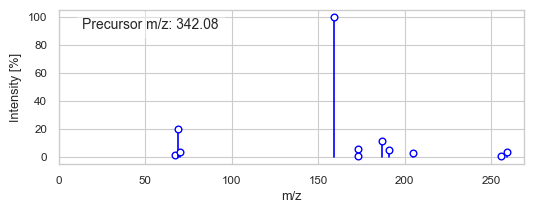

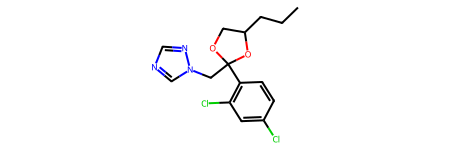

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020718', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}
16932


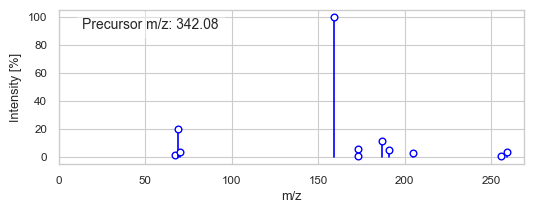

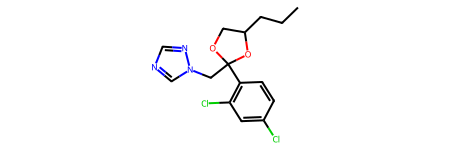

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020758', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}
16937


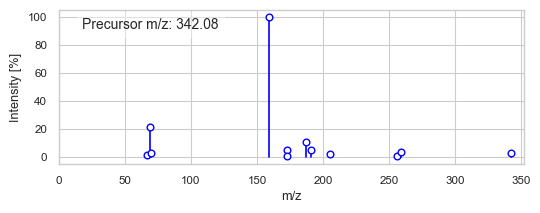

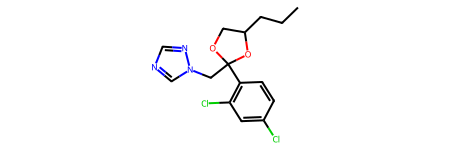

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020764', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


In [21]:
# Pick some LSH forming a cluster of 5 spectra
lsh_counts = pd.Series(hashes).value_counts()
lsh_i = lsh_counts[lsh_counts == 5].index[703]
idx = np.where(hashes == lsh_i)[0]

# Display clustered spectra
for i in idx:
    print(msdata.at(int(i), plot_mol=True))

In [18]:
from paths import PROJECT_ROOT
from benchmark.utils.plots import set_project_root, export_spectra_mol

set_project_root(PROJECT_ROOT)

In [22]:
# Pick some LSH forming a cluster of 5 spectra
lsh_counts = pd.Series(hashes).value_counts()
lsh_i = lsh_counts[lsh_counts == 5].index[703]
idx = np.where(hashes == lsh_i)[0]

/var/folders/bl/73ckjztx5js4cc0cj85qgvlm0000gn/T/ipykernel_83096/1652155773.py:2: FutureWarning: The behavior of value_counts with object-dtype is deprecated. In a future version, this will *not* perform dtype inference on the resulting index. To retain the old behavior, use `result.index = result.index.infer_objects()`
  lsh_counts = pd.Series(hashes).value_counts()


In [23]:
idx

array([16879, 16883, 16893, 16932, 16937])

In [26]:
lsh_i

b'0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d'

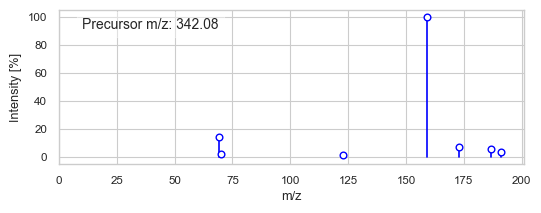

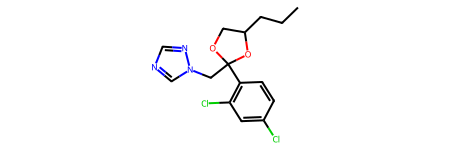

{'COLLISION_ENERGY': 40.0, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020702', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'QTOF', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


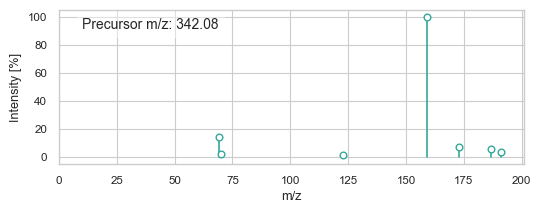

saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16879_spectrum.svg  |  /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16879_molecule.svg


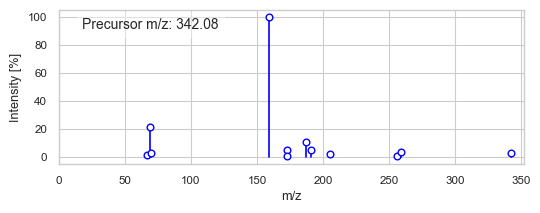

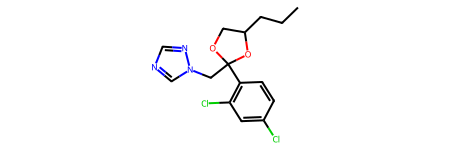

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020706', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


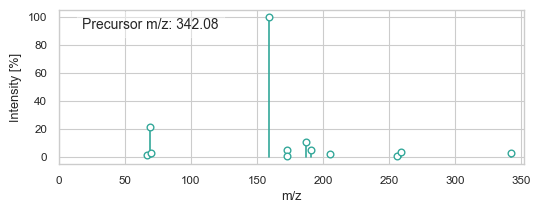

saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16883_spectrum.svg  |  /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16883_molecule.svg


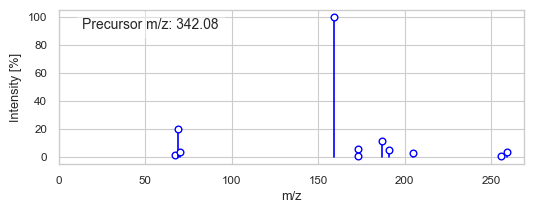

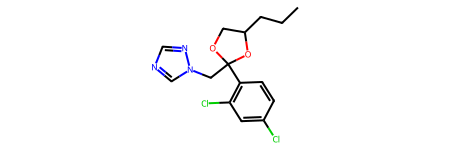

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020718', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


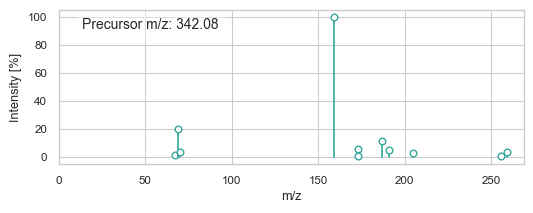

saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16893_spectrum.svg  |  /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16893_molecule.svg


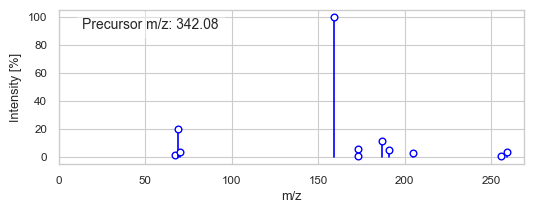

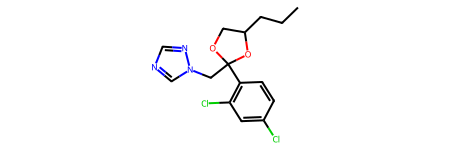

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020758', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


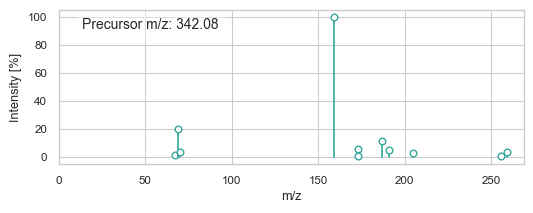

saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16932_spectrum.svg  |  /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16932_molecule.svg


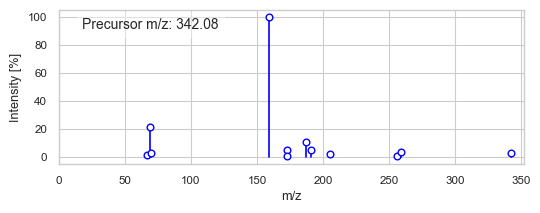

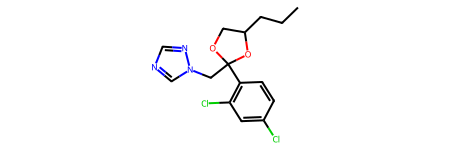

{'COLLISION_ENERGY': 30.786938999999997, 'FOLD': 'train', 'FORMULA': 'C15H17Cl2N3O2', 'IDENTIFIER': 'MassSpecGymID0020764', 'INCHIKEY': 'STJLVHWMYQXCPB', 'INSTRUMENT_TYPE': 'Orbitrap', 'PARENT_MASS': 341.069824, 'PRECURSOR_FORMULA': 'C15H18Cl2N3O2', 'SIMULATION_CHALLENGE': 'True', 'adduct': '[M+H]+', 'precursor_mz': 342.0771, 'smiles': 'CCCC1COC(O1)(CN2C=NC=N2)C3=C(C=C(C=C3)Cl)Cl'}


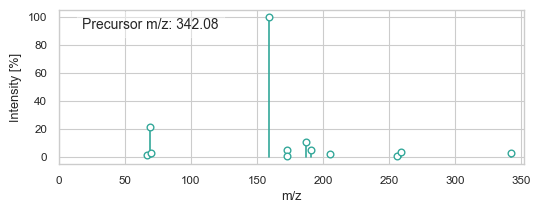

saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16937_spectrum.svg  |  /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d_idx16937_molecule.svg


In [27]:
from benchmark.utils.plots import export_spectra_mol

# hash tag as string for filenames/folders
cluster_tag = lsh_i.decode("ascii") if isinstance(lsh_i, (bytes, bytearray)) else str(lsh_i)
cluster_dir = f"clusters/{cluster_tag}"

for i in sorted(map(int, idx)):
    # your usual on-screen view
    print(msdata.at(i, plot_mol=True))

    # save SVGs (spectrum + molecule) with the index baked into the name
    spec_path, mol_path = export_spectra_mol(
        msdata, i,
        basename=f"{cluster_tag}_idx{i}",
        spec_rel_dir=cluster_dir, mol_rel_dir=cluster_dir,
        spec_ext="svg", mol_ext="svg",
        smiles_col="smiles",
        figsize=(6, 2), colors="nature", normalize_intensities=True
    )
    print("saved:", spec_path, " | ", mol_path)

In [28]:
idx_inchi = np.where(np.array(msdata['INCHIKEY']) == 'RHMXXJGYXNZAPX')[0]
idx_inchi.shape

(46,)

In [30]:
cos_sim = PeakListModifiedCosine()
cos_sim.compute_pairwise(specs=msdata['spectrum'][idx], prec_mzs=msdata['precursor_mz'][idx], avg=False)

array([[1.        , 0.99442721, 0.99534008, 0.99523699, 0.99430585],
       [0.99442721, 1.        , 0.99940281, 0.99938881, 0.99999786],
       [0.99534008, 0.99940281, 1.        , 0.99999852, 0.99939452],
       [0.99523699, 0.99938881, 0.99999852, 1.        , 0.99938259],
       [0.99430585, 0.99999786, 0.99939452, 0.99938259, 1.        ]])

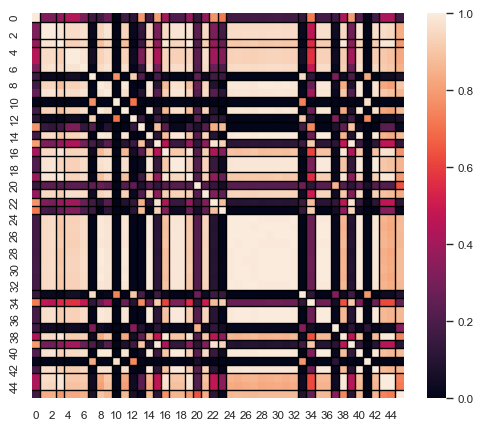

In [31]:
# Sort idx_inchi by their lshs
idx_inchi = idx_inchi[np.argsort(hashes[idx_inchi])]
idx_inchi

# Plot heatmap of pairwise modified cosine similarities
init_plotting(figsize=(6, 5))
sns.heatmap(cos_sim.compute_pairwise(specs=msdata['spectrum'][idx_inchi], prec_mzs=msdata['precursor_mz'][idx_inchi], avg=False), linewidth=0)

# Draw LSH boundaries
for i, (a, b) in enumerate(zip(hashes[idx_inchi], hashes[idx_inchi][1:])):
    if a != b:
        plt.axvline(i + 1, color='black', linewidth=1)
        plt.axhline(i + 1, color='black', linewidth=1)

plt.show()


saved: /Users/macbook/CODE/DreaMS_MIMB/misc/figures/clusters/0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d/heatmap_0aef08d8cece052a4b6c0f39a0dfa2003819d2d6ff470324cc64ab472dcfbf0d.svg


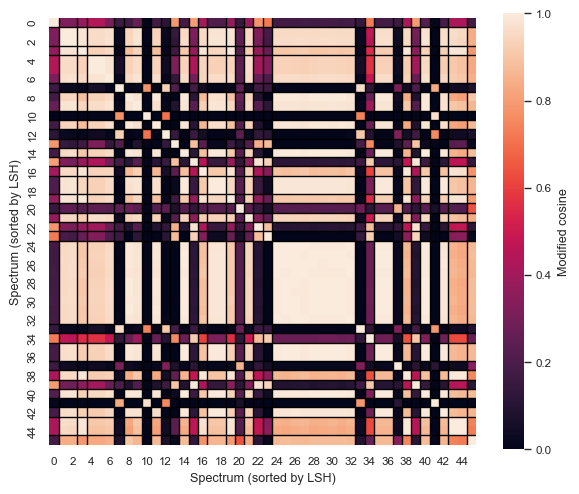

In [32]:
from pathlib import Path
from paths import PROJECT_ROOT

# tag & output path
cluster_tag = lsh_i.decode("ascii") if isinstance(lsh_i, (bytes, bytearray)) else str(lsh_i)
out = Path(PROJECT_ROOT) / "misc" / "figures" / "clusters" / cluster_tag / f"heatmap_{cluster_tag}.svg"
out.parent.mkdir(parents=True, exist_ok=True)

# Sort idx_inchi by their LSHs
idx_inchi = idx_inchi[np.argsort(hashes[idx_inchi])]

# Plot heatmap
init_plotting(figsize=(6, 5))
mat = cos_sim.compute_pairwise(
    specs=msdata["spectrum"][idx_inchi],
    prec_mzs=msdata["precursor_mz"][idx_inchi],
    avg=False
)
ax = sns.heatmap(mat, linewidth=0, square=True, cbar_kws={"label": "Modified cosine"})

# Draw LSH boundaries
h = hashes[idx_inchi]
for i, (a, b) in enumerate(zip(h, h[1:])):
    if a != b:
        plt.axvline(i + 1, color="black", linewidth=1)
        plt.axhline(i + 1, color="black", linewidth=1)

plt.xlabel("Spectrum (sorted by LSH)")
plt.ylabel("Spectrum (sorted by LSH)")
plt.tight_layout()

# Save as SVG (Illustrator-ready)
plt.savefig(str(out), format="svg", bbox_inches="tight", pad_inches=0.05)
print("saved:", out)